In [1554]:
#for binary classifiaction type problems , we use it rather than using the jugad techniques
#but in those problem , we have a issue , that , we will not get the best possible , or best optimized , line  many possible  lines we can get there , so , we have to use the perceptron loss, using the SGD here
#it helps us to get the exact values or the most optimised weights , here , applied for the linearly seperable binary classification type datas

In [1555]:
import numpy as np
import pandas as pd

In [1556]:
from sklearn.datasets import make_classification

In [1557]:
X,y = make_classification(n_samples = 100,n_features = 2, n_informative = 2, n_redundant=0, n_classes = 2, n_clusters_per_class = 1)

In [1558]:
arr  = np.hstack((X,y.reshape(-1,1)))

In [1559]:
df = pd.DataFrame(arr, columns = ['x1','x2','y'])
df

,x1,x2,y
0,1.690080,-1.040923,1.0
1,-2.416138,0.171526,0.0
2,-0.040743,-1.817607,0.0
3,0.842477,-2.471209,0.0
4,1.682557,-0.998228,1.0
...,...,...,...
95,0.987994,-1.219743,1.0
96,-2.415795,0.273265,0.0
97,-1.341856,-0.581714,0.0
98,-2.216939,-0.008494,0.0


In [1560]:
import seaborn as sns

<Axes: xlabel='x1', ylabel='x2'>

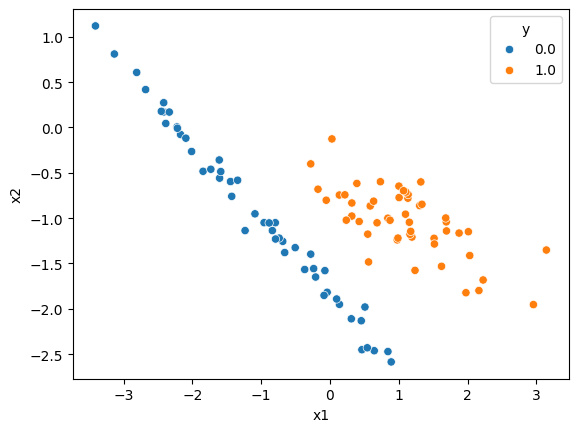

In [1561]:
sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = 'y')

In [1562]:
df['y'].replace({0:-1},inplace = True)

/tmp/ipykernel_811/870324133.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['y'].replace({0:-1},inplace = True)


In [1563]:
df

,x1,x2,y
0,1.690080,-1.040923,1.0
1,-2.416138,0.171526,-1.0
2,-0.040743,-1.817607,-1.0
3,0.842477,-2.471209,-1.0
4,1.682557,-0.998228,1.0
...,...,...,...
95,0.987994,-1.219743,1.0
96,-2.415795,0.273265,-1.0
97,-1.341856,-0.581714,-1.0
98,-2.216939,-0.008494,-1.0


In [1564]:
#perceptron_loss
#yi = {-1,+1}
#f(xi) = wTxi + b
#it only updates the weights for the missclassified points here
#if yi.f(xi) >= 0 no updates in the weights its rightly classified
#if yi.f(xi) < 0 updates in the weights its misclassified -> then the slope will become -yi.xi1, or -yi.xi2 dpens upon which weights its updating

In [1565]:
def UKD_perceptron_loss_SGD(df, epochs = 100, learning_rate = 0.01):
  design_matrix = np.insert(df.drop(columns = 'y').values,0,1,axis = 1)
  df['y'] = df['y'].replace({0:-1})
  w = np.ones(shape = df.shape[1])
  w[0] = 0
  for i in range(epochs):
    df = df.sample(df.shape[0])
    for j in df.index:
      if y[j]*np.dot(w,design_matrix[j,:]) < 0:
        w = w + learning_rate * y[j]*design_matrix[j,:]
      else :
        w = w
  return w


In [1566]:
w = UKD_perceptron_loss_SGD(df)
weights = w[1:]
bias = w[0]
print(bias)
print(weights)

0.5700000000000003
[1.07801904 0.54029512]


In [1567]:
x_point = np.linspace(min(df['x1']),max(df['x1']),100)

In [1568]:
y_point = [-bias/weights[1]] - [weights[0]/weights[1]]*x_point

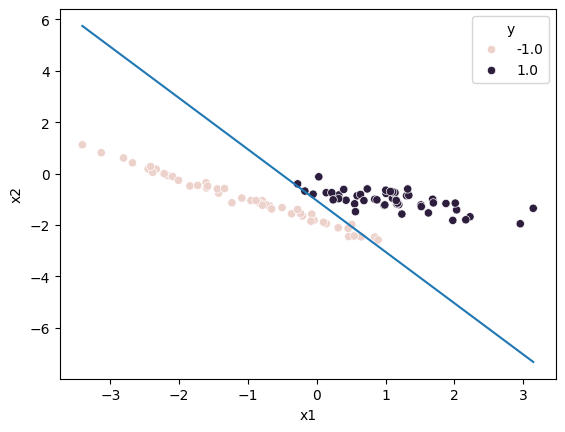

In [1569]:
import matplotlib.pyplot as plt
sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = 'y')
plt.plot(x_point,y_point)

In [1570]:
# more better

def UKD_perceptron_loss_SGD_better(df, epochs=100, learning_rate=0.01):

    df = df.copy()
    df['y'] = df['y'].replace({0: -1})

    w = np.ones(df.shape[1])
    w[0] = 0

    for i in range(epochs):

        df = df.sample(frac=1).reset_index(drop=True)

        X = np.insert(
            df.drop(columns='y').values,
            0,
            1,
            axis=1
        )

        y = df['y'].values

        for j in range(len(df)):

            if y[j] * np.dot(w, X[j]) <= 0:
                w += learning_rate * y[j] * X[j]

    return w

In [1571]:
w1 = UKD_perceptron_loss_SGD_better(df)
weights1 = w1[1:]
bias1 = w1[0]
print(bias1)
print(weights1)

0.5900000000000003
[1.01908232 0.60595427]


In [1572]:
x_point_new = np.linspace(min(df['x1']),max(df['x1']),100)

In [1573]:
y_point_new = (-bias1/weights1[1]) - (weights1[0]/weights1[1])*x_point_new

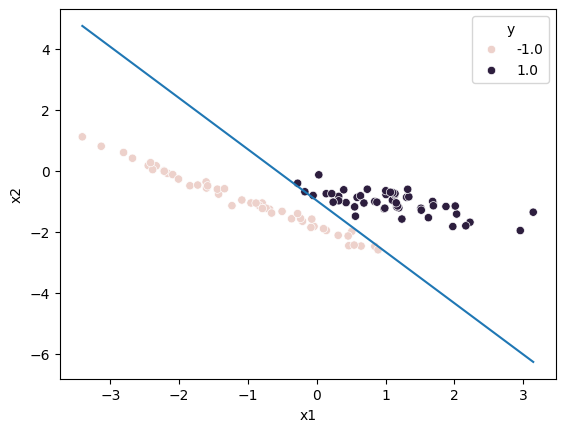

In [1574]:
import matplotlib.pyplot as plt
sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = 'y')
plt.plot(x_point_new,y_point_new)

In [1575]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# from sklearn.datasets import make_blobs
# from IPython.display import HTML

# # -------------------------------------------------------
# # Generate linearly separable data
# # -------------------------------------------------------

# from sklearn.datasets import make_moons

# X, y = make_moons(
#     n_samples=150,
#     noise=0.15,
#     random_state=42
# )

# y = np.where(y==0,-1,1)

# # Convert labels to {-1,+1}

# # Add bias column
# X_bias = np.insert(X, 0, 1, axis=1)

# # -------------------------------------------------------
# # Perceptron SGD
# # -------------------------------------------------------

# lr = 0.1
# epochs = 5

# w = np.zeros(3)

# history = []

# for epoch in range(epochs):

#     idx = np.random.permutation(len(X_bias))

#     mistakes = 0

#     for i in idx:

#         # Save BEFORE update
#         history.append((w.copy(), i, epoch))

#         if y[i] * np.dot(w, X_bias[i]) <= 0:

#             w = w + lr * y[i] * X_bias[i]

#             mistakes += 1

#             # Save AFTER update
#             history.append((w.copy(), i, epoch))

#     print(f"Epoch {epoch+1} : mistakes = {mistakes}")

#     if mistakes == 0:
#         print("Converged!")
#         break

# print("\nFinal weights:")
# print(w)

# # -------------------------------------------------------
# # Animation
# # -------------------------------------------------------

# fig, ax = plt.subplots(figsize=(8,6))

# xmin = X[:,0].min() - 1
# xmax = X[:,0].max() + 1

# ymin = X[:,1].min() - 1
# ymax = X[:,1].max() + 1


# def animate(frame):

#     ax.clear()

#     weights, sample_idx, epoch = history[frame]

#     # Plot points

#     for i in range(len(X)):

#         if y[i] == -1:
#             ax.scatter(
#                 X[i,0],
#                 X[i,1],
#                 color='red',
#                 s=50
#             )
#         else:
#             ax.scatter(
#                 X[i,0],
#                 X[i,1],
#                 color='blue',
#                 s=50
#             )

#     # Highlight current point

#     ax.scatter(
#         X[sample_idx,0],
#         X[sample_idx,1],
#         s=300,
#         facecolors='none',
#         edgecolors='black',
#         linewidths=3
#     )

#     # Draw decision boundary

#     if abs(weights[2]) > 1e-8:

#         xx = np.linspace(xmin, xmax, 200)

#         yy = -(weights[0] + weights[1]*xx)/weights[2]

#         ax.plot(
#             xx,
#             yy,
#             color='green',
#             linewidth=3
#         )

#     ax.set_xlim(xmin, xmax)
#     ax.set_ylim(ymin, ymax)

#     ax.set_title(
#         f"Epoch : {epoch+1}\n"
#         f"Current Sample : {sample_idx}\n"
#         f"Weights : {np.round(weights,2)}"
#     )

#     ax.set_xlabel("x1")
#     ax.set_ylabel("x2")


# ani = FuncAnimation(
#     fig,
#     animate,
#     frames=len(history),
#     interval=250,
#     repeat=False
# )

# plt.close()

# HTML(ani.to_jshtml())